**Ejecucion**

Azeótropo aproximado:
x1 = 0.6122
y1 = 0.6275
P  = 35.1271 bar


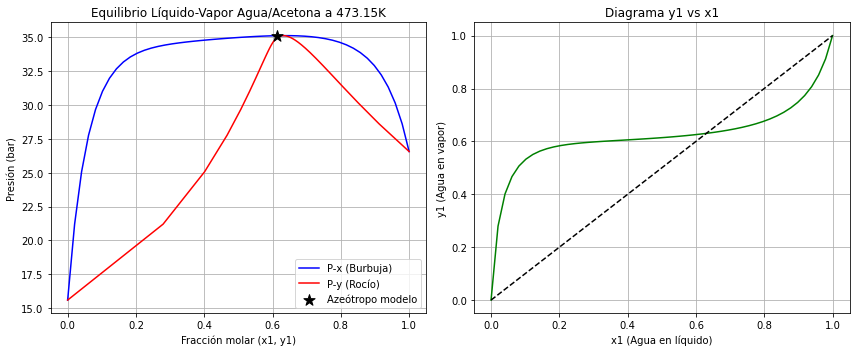

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

# Componente 1: Acetona, Componente 2: Agua
R = 8.314472e-5  # bar * m3 / (mol * K)

comp_data = {
    'agua': {
        'Tc': 647.1, 'Pc': 220.55,
        'antoine': [5.11564, 1687.537, 230.17], # log10(P/bar), T en C
        'V_molar_liq': 18.02e-6 # m3/mol 
    },
    'acetona': {
        'Tc': 508.1, 'Pc': 47.0,
        'antoine': [4.2184, 1197.01, 228.41],
        'V_molar_liq': 74.0e-6 # m3/mol
    }
}

T = 473.15 # K 


def get_psat(temp, species):
    """Calcula Psat en bar usando Antoine"""
    A, B, C = comp_data[species]['antoine']
    t_celsius = temp - 273.15
    return 10**(A - B / (t_celsius + C))

def vanDerWaals_phi(T, P, y, species_list):
    """
    Calcula el coeficiente de fugacidad (phi) usando Peng-Robinson.
    Retorna [phi1, phi2]
    """
    # Esta es una versión simplificada de la expresión analítica
    # En un sistema real, aquí integrarías la expresión de la imagen_b1a638.png

    phis = []
    
    a1 = ((27/64)*(comp_data[species_list[0]]['Tc']*R)**2/comp_data[species_list[0]]['Pc']) 
    b1 = R*comp_data[species_list[0]]['Tc']/(8*comp_data[species_list[0]]['Pc']) 

    a2 = ((27/64)*(comp_data[species_list[1]]['Tc']*R)**2/comp_data[species_list[1]]['Pc']) 
    b2 = R*comp_data[species_list[1]]['Tc']/(8*comp_data[species_list[1]]['Pc']) 

    a = [a1, a2]
    b = [b1, b2]

    amix = a[0]*y[0]**2 + a[1]*(1-y[0])**2 + 2*y[0]*(1-y[0])*(a[0]*a[1])**(1/2)
    bmix = y[0]*b[0] + (1-y[0])*b[1]

    # print(f"a1 = {a1}, a2 = {a2}, b1 = {b1}, b2 = {b2}, amix = {amix}, bmix = {bmix}, y = {y}")

    for i in range(len(y)):
        coeffs = [P, -(R*T + P*bmix), (amix), (-amix*bmix)]
        roots = np.roots(coeffs)
        vV = np.max(roots[np.isreal(roots)].real) #volumen del vapor
        zV = P*vV/(R*T)
        
        ln_phi = R*T*np.log(vV/(vV - bmix)) + R*T*b[0]/(vV - bmix) - 2*y[i]*a[0] + 2*(1-y[i])*(a[0]*a[1])**(1/2)/(vV) - R*T*np.log(zV)
        phis.append(np.exp(ln_phi))
    return np.array(phis)
    # phis = phi_1, phi_2 -> Cuando necesite el de una sustancia pura, solo mando y1 = 1 o y1 = 0, y escogo el phi de la sustancia pura que me interesa. 

def activity_coefficients(x, T):
    """
    Simulación de UNIFAC / NRTL.
    A 473K el sistema Agua-Acetona tiene una desviación positiva.
    """
    
    # Grupos: 0 = CH3, 1 = CH3CO, 2 = H2O
    # Molecula 1 (Acetona): 1x CH3, 1x CH3CO, 0x H2O
    # Molecula 2 (Agua): 0x CH3, 0x CH3CO, 1x H2O
    nu = np.array([
        [1, 1, 0],  
        [0, 0, 1]   
    ])
    
    R_k = np.array([0.9011, 1.6724, 0.92])
    Q_k = np.array([0.848, 1.488, 1.40])
    
    a_mn = np.array([
        [0.0,472.6, 1300],    
        [66.56, 0.0, 634.8],    
        [342.4, -171.8, 0.0]   
    ])
    

    Psi = np.exp(-a_mn / T)
    z = 10.0
    

    r = np.sum(nu * R_k, axis=1)
    q = np.sum(nu * Q_k, axis=1)
    l = (z / 2) * (r - q) - (r - 1)
    
    GE_RT_list = []

    
    Phi = (x * r) / np.sum(x * r)
    Theta = (x * q) / np.sum(x * q)

    if x[0] == 1:
        epsilon = 1e-10
        x_inf = np.array([1.0 - epsilon, epsilon])
        gamma_inf = activity_coefficients(x_inf, T)
        return np.array([1, gamma_inf[1]])
    
    elif x[1] == 1:
        epsilon = 1e-10
        x_inf = np.array([epsilon, 1.0 -  epsilon])
        gamma_inf = activity_coefficients(x_inf, T)
        return np.array([gamma_inf[0], 1])
        
    ln_gamma_C = np.log(Phi / x) + (z / 2) * q * np.log(Theta / Phi) + l - (Phi / x) * np.sum(x * l)
    
    # Residual
    sum_nu_x = np.sum(x[:, np.newaxis] * nu, axis=0) 
    X_m = sum_nu_x / np.sum(sum_nu_x)
    Theta_m = X_m * Q_k / np.sum(X_m * Q_k)
    
    # ln Gamma_k
    ln_Gamma_k = np.zeros(3)
    for k in range(3):
        term1 = np.sum(Theta_m * Psi[:, k])
        term2 = sum((Theta_m[m] * Psi[k, m]) / np.sum(Theta_m * Psi[:, m]) for m in range(3))
        ln_Gamma_k[k] = Q_k[k] * (1 - np.log(term1) - term2)
        
    #ln Gamma_k_i
    ln_Gamma_k_i = np.zeros((2, 3))
    for i in range(2):
        X_m_i = nu[i] / np.sum(nu[i])
        Theta_m_i = X_m_i * Q_k / np.sum(X_m_i * Q_k)
        for k in range(3):
            if nu[i, k] > 0:
                term1 = np.sum(Theta_m_i * Psi[:, k])
                term2 = sum((Theta_m_i[m] * Psi[k, m]) / np.sum(Theta_m_i * Psi[:, m]) for m in range(3) if Theta_m_i[m] > 0)
                ln_Gamma_k_i[i, k] = Q_k[k] * (1 - np.log(term1) - term2)
                
    # 4. ln_Gamma_R
    ln_gamma_R = np.zeros(2)
    for i in range(2):
        ln_gamma_R[i] = np.sum(nu[i] * (ln_Gamma_k - ln_Gamma_k_i[i]))
        
    # GE
    ln_gamma = ln_gamma_C + ln_gamma_R


    return np.array([np.exp(ln_gamma[0]), np.exp(ln_gamma[1])])


x1_range = np.linspace(0, 1, 50)
results_P = []
results_y1 = []

P2_sat = get_psat(T, 'agua')
P1_sat = get_psat(T, 'acetona')


phi_sat1 = vanDerWaals_phi(T, P1_sat, [1.0, 0.0], ['agua', 'acetona'])[0]
phi_sat2 = vanDerWaals_phi(T, P2_sat, [0.0, 1.0], ['agua', 'acetona'])[1]


# print(f"phi 1 Sat = {phi_sat1}, phi 2 Sat = {phi_sat2}")

for x1 in x1_range:
    x = np.array([x1, 1-x1])
    gamma = activity_coefficients(x, T)
    
    P_guess = x[0]*gamma[0]*P1_sat + x[1]*gamma[1]*P2_sat
    y1_guess = (x[0]*gamma[0]*P1_sat) / P_guess
    
    def residuals(vars):
        P_curr, y1_curr = vars
        y_curr = np.array([y1_curr, 1-y1_curr])
        
        phi = vanDerWaals_phi(T, P_curr, y_curr, ['agua', 'acetona'])
        
        v2 = comp_data['agua']['V_molar_liq']
        v1 = comp_data['acetona']['V_molar_liq']
        #I do not approve of FP calculation -> Arreglar ahorita con una funcion
        FP2 = np.exp(v2 * (P_curr - P2_sat) / (R * T))
        FP1 = np.exp(v1 * (P_curr - P1_sat) / (R * T))
        
        # Ecuaciones de equilibrio: phi_i * yi * P = xi * gamma_i * phi_sat_i * Psat_i * FPi
        res1 = phi[0] * y_curr[0] * P_curr - x[0] * gamma[0] * phi_sat1 * P1_sat * FP1
        res2 = phi[1] * y_curr[1] * P_curr - x[1] * gamma[1] * phi_sat2 * P2_sat * FP2
        return [res1, res2]

    sol = fsolve(residuals, [P_guess, y1_guess])
    results_P.append(sol[0])
    results_y1.append(sol[1])

diff = np.abs(np.array(x1_range) - np.array(results_y1))[1:-1]
azeo_idx = np.argmin(diff)

azeo_x = x1_range[azeo_idx]
azeo_y = results_y1[azeo_idx]
azeo_P = results_P[azeo_idx]

print(f"Azeótropo aproximado:")
print(f"x1 = {azeo_x:.4f}")
print(f"y1 = {azeo_y:.4f}")
print(f"P  = {azeo_P:.4f} bar")


plt.figure(figsize=(12, 5))

# Gráfico P-x-y
plt.subplot(1, 2, 1)
plt.plot(x1_range, results_P, 'b-', label='P-x (Burbuja)')
plt.plot(results_y1, results_P, 'r-', label='P-y (Rocío)')

plt.scatter(azeo_x, azeo_P,
            s=140,
            marker='*',
            color='black',
            zorder=5,
            label='Azeótropo modelo')

plt.title(f'Equilibrio Líquido-Vapor Agua/Acetona a {T}K')
plt.xlabel('Fracción molar (x1, y1)')
plt.ylabel('Presión (bar)')
plt.legend()
plt.grid(True)

# Gráfico y-x
plt.subplot(1, 2, 2)
plt.plot(x1_range, results_y1, 'g-')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('Diagrama y1 vs x1')
plt.xlabel('x1 (Agua en líquido)')
plt.ylabel('y1 (Agua en vapor)')
plt.grid(True)

plt.tight_layout()
plt.show()

**Experimental Data**

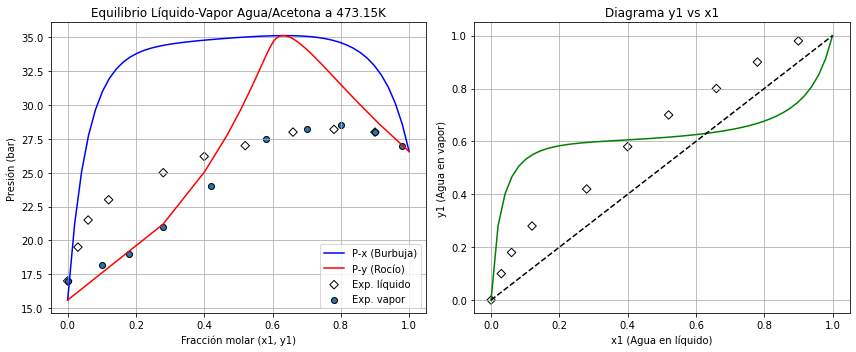

In [2]:
gas_data = [
    (0.00, 17.0),
    (0.10, 18.2),
    (0.18, 19.0),
    (0.28, 21.0),
    (0.42, 24.0),
    (0.58, 27.5),
    (0.70, 28.2),
    (0.80, 28.5),
    (0.90, 28.0),
    (0.98, 27.0)
]


liquid_data = [
    (0.00, 17.0),
    (0.03, 19.5),
    (0.06, 21.5),
    (0.12, 23.0),
    (0.28, 25.0),
    (0.40, 26.2),
    (0.52, 27.0),
    (0.66, 28.0),
    (0.78, 28.2),
    (0.90, 28.0)
]


x_exp, P_liq_exp = zip(*liquid_data)
y_exp, P_gas_exp = zip(*gas_data)



plt.figure(figsize=(12, 5))

# Gráfico P-x-y
plt.subplot(1, 2, 1)
plt.plot(x1_range, results_P, 'b-', label='P-x (Burbuja)')
plt.plot(results_y1, results_P, 'r-', label='P-y (Rocío)')

plt.scatter(x_exp, P_liq_exp,
            marker='D',
            facecolors='none',
            color='black',
            label='Exp. líquido')

plt.scatter(y_exp, P_gas_exp,
            marker='o',
            edgecolors='black',
            label='Exp. vapor')


plt.title(f'Equilibrio Líquido-Vapor Agua/Acetona a {T}K')
plt.xlabel('Fracción molar (x1, y1)')
plt.ylabel('Presión (bar)')
plt.legend()
plt.grid(True)

# Gráfico y-x
plt.subplot(1, 2, 2)
plt.plot(x1_range, results_y1, 'g-')
plt.plot([0, 1], [0, 1], 'k--')

plt.scatter(x_exp, y_exp,
            marker='D',
            facecolors='none',
            color='black',
            label='Datos experimentales')

plt.title('Diagrama y1 vs x1')
plt.xlabel('x1 (Agua en líquido)')
plt.ylabel('y1 (Agua en vapor)')
plt.grid(True)

plt.tight_layout()
plt.show()